In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from skimage import exposure

In [2]:
def hair_coverage_dark(img_gray):

    # blur image to remove noise
    img_gray = cv2.medianBlur(img_gray, 9)

    # kernel and BlackHat mask
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (45, 45))
    blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, 50, 255, cv2.THRESH_BINARY)

    # total number of pixels in the image
    total_area = img_gray.shape[0] * img_gray.shape[1]

    # number of hair pixels from mask (white region)
    hair_area = np.sum(hair_mask == 255)

    coverage = hair_area / total_area
    
    return round(coverage, 4)

In [3]:
def hair_coverage_light(img_gray):

    # blur image to remove noise
    img_gray = cv2.medianBlur(img_gray, 9)

    # kernel and TopHat mask
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (21, 21))
    tophat = cv2.morphologyEx(img_gray, cv2.MORPH_TOPHAT, kernel)
    _, hair_mask = cv2.threshold(tophat, 75, 255, cv2.THRESH_BINARY)
    
    # total number of pixels in the image
    total_area = img_gray.shape[0] * img_gray.shape[1]

    # number of hair pixels from mask (white region)
    hair_area = np.sum(hair_mask == 255)

    # ratio of hair pixels to total pixels
    coverage = hair_area / total_area
    
    return round(coverage, 4)

In [ ]:
df = pd.read_csv("annotations_combined.csv")
clean = pd.read_csv("../data/clean_data_with_splits.csv")
clean = clean[clean["group_id"].isin(["a", "b", "c", "d"])]         # test groups
df = df[df["img_id"].isin(list(clean["img_id"]))]

# ensure clean filenames
df["img_id"] = df["img_id"].astype(str).str.strip()
df["img_id"] = df["img_id"].apply(lambda x: x if x.endswith(".png") else x + ".png")

hair_cols = ["hair_1", "hair_2", "hair_3", "hair_4", "hair_5"]

#drop missing values
df = df.dropna(subset=hair_cols)
# Compute the average hair score per image
df["hair_mean"] = df[hair_cols].mean(axis=1)
df["hair_label"] = df["hair_mean"].round().astype(int)

base_path = "../data/imgs"
haircoverage_values = []
labels = []

for img_id, label in zip(df["img_id"], df["hair_label"]):
    img_path = os.path.join(base_path, img_id)
    img = cv2.imread(img_path)
    if img is None:
        continue
    # convert image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # apply contrast
    p2, p98 = np.percentile(gray, (2, 98))
    gray = exposure.rescale_intensity(gray, in_range=(p2, p98))

    dark = hair_coverage_dark(gray)
    light = hair_coverage_light(gray)
    total = dark + light
    # append hair coverage value
    haircoverage_values.append(total)   
    # append mean annotation label 
    labels.append(label)        

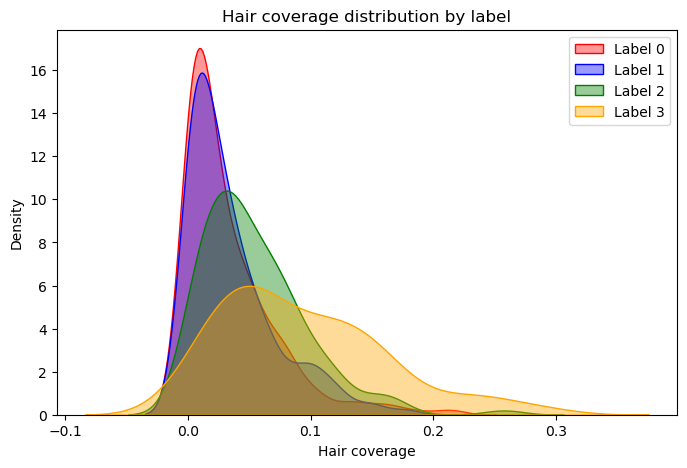

In [ ]:
# convert haircoverage_values and labels into numpy arrays
haircoverage_values = np.array(haircoverage_values)
labels = np.array(labels)
# get the unique labels (0, 1, 2, 3)
groups = np.unique(labels)
# colours for each label
colors = ["red", "blue", "green", "orange"]

plt.figure(figsize=(8, 5))
for group, color in zip(groups, colors):
    # Select only the coverage values that belong to a particular group
    group_values = haircoverage_values[labels == group]
    # density curves
    sns.kdeplot(group_values, fill=True, alpha=0.4, color=color, label=f"Label {group}")

plt.xlabel("Hair coverage")
plt.ylabel("Density")
plt.title("Hair coverage distribution by label")
plt.legend()
plt.show()

In [ ]:
# AUTOMATIC METHOD

def removeHair_auto(img_org):
    # convert to gray
    gray = cv2.cvtColor(img_org, cv2.COLOR_BGR2GRAY)
    # contrtast
    p2, p98 = np.percentile(gray, (2, 98))
    gray = exposure.rescale_intensity(gray, in_range=(p2, p98))

    black = hair_coverage_dark(gray)
    white = hair_coverage_light(gray)
    coverage = black + white

    if coverage < 0.03:
        kernel_size_b = 30
        kernel_size_w = 15
        threshold_b = 50
        threshold_w = 85
    elif coverage < 0.09:
        kernel_size_b = 45
        kernel_size_w = 20
        threshold_b = 40
        threshold_w = 75
    elif coverage > 0.18:
        return img_org
    else:
        kernel_size_b = 50
        kernel_size_w = 30
        threshold_b = 30
        threshold_w = 60

    # black hat
    kernel_black = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size_b, kernel_size_b))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel_black)
    _, mask_black = cv2.threshold(blackhat, threshold_b, 255, cv2.THRESH_BINARY)
    img_1 = cv2.inpaint(img_org, mask_black, 3, cv2.INPAINT_TELEA)

    # top hat after black hat
    gray = cv2.cvtColor(img_1, cv2.COLOR_BGR2GRAY)
    p2, p98 = np.percentile(gray, (2, 98))
    gray = exposure.rescale_intensity(gray, in_range=(p2, p98))

    kernel_white = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size_w, kernel_size_w))
    tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel_white)
    _, mask_top = cv2.threshold(tophat, threshold_w, 255, cv2.THRESH_BINARY)

    img_2 = cv2.inpaint(img_1, mask_top, 3, cv2.INPAINT_TELEA)
    
    return img_2, coverage

In [ ]:
data = pd.read_csv("../data/clean_data_with_splits.csv")
os.makedirs("shortcuts images", exist_ok=True)
base_path = "../data/imgs"
haircoverage_values = []        # hair coverage feature

for img_id in data["img_id"]:
    img_path = os.path.join(base_path, img_id)
    img = cv2.imread(img_path)
    if img is None:
        haircoverage_values.append(0)
        continue
    img_out, coverage = removeHair_auto(img)
    haircoverage_values.append(coverage)
    cv2.imwrite(f"shortcuts images/{img_id}", img_out)